## CAPSTON PROJECT 3:

Social Media Usage and Emotional Well-Being
PREPARED BY YOGESH SINGH BATCH 13

In [106]:
# Importing necessary libraries for data manipulation
import pandas as pd  # Powerful data structures for data analysis, time series, and statistics
import numpy as np  # Fundamental package for scientific computing with Python

# Importing libraries for data visualization
import seaborn as sns  # Statistical data visualization
import matplotlib.pyplot as plt  # Plotting library for Python

# Importing machine learning utilities
from sklearn.model_selection import train_test_split  # Utility to split the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler  # Standardize features by removing the mean and scaling to unit variance
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  # Metrics to evaluate the performance of a model
from sklearn.preprocessing import LabelEncoder # Label Encoder

# Importing TensorFlow libraries for building the GRU model
import tensorflow as tf  # Deep learning library
from tensorflow.keras.models import Sequential  # Sequential model type from Keras
from tensorflow.keras.layers import Dense, GRU, Dropout  # Layers used to build the neural network
from tensorflow.keras.utils import to_categorical # Categorical of data

# Setting visualization styles
sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)  # Setting default figure size for plots

# Fix the seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Print TensorFlow version
print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


In [107]:
import numpy as np
import pandas as pd
import os

In [108]:
# Load the datasets
train_df = pd.read_csv('train.csv', on_bad_lines='skip')
test_df = pd.read_csv('test.csv', on_bad_lines='skip')
val_df = pd.read_csv('val.csv', on_bad_lines='skip')

# Display the first few rows of the training data
print("First 5 rows of the training data:")
train_df.head()

First 5 rows of the training data:


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## 2.2 Understanding the Data¶

Let's explore the basic structure of the DataFrames to understand the data we are working with. We will look at data types, summary statistics, and check for any missing values.

In [109]:
# Display the structure of the training data
print("Information about the training data:")
train_df.info()

# Display summary statistics
print("\nSummary statistics of the training data:")
train_df.describe()

# Check for missing values
print("\nMissing values in the training data:")
train_df.isnull().sum()

Information about the training data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 78.3+ KB

Summary statistics of the training data:

Missing values in the training data:


,0
User_ID,0
Age,0
Gender,1
Platform,1
Daily_Usage_Time (minutes),1
Posts_Per_Day,1
Likes_Received_Per_Day,1
Comments_Received_Per_Day,1
Messages_Sent_Per_Day,1
Dominant_Emotion,1


In [110]:
print("Information about the training data:")
train_df.info()

print("\nSummary statistics of the training data:")
train_df.describe()

print("\nMissing values in the training data:")
train_df.isnull().sum()

Information about the training data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 78.3+ KB

Summary statistics of the training data:

Missing values in the training data:


,0
User_ID,0
Age,0
Gender,1
Platform,1
Daily_Usage_Time (minutes),1
Posts_Per_Day,1
Likes_Received_Per_Day,1
Comments_Received_Per_Day,1
Messages_Sent_Per_Day,1
Dominant_Emotion,1


## 2.3 Preview the Test and Validation Data¶
Let's also take a quick look at the test and validation datasets to ensure they have similar structures to the training dataset.

In [111]:
# Display the first few rows of the test data
print("First 5 rows of the test data:")
test_df.head()

# Check for missing values in the test data
print("\nMissing values in the test data:")
test_df.isnull().sum()

# Display the first few rows of the validation data
print("First 5 rows of the validation data:")
val_df.head()

# Check for missing values in the validation data
print("\nMissing values in the validation data:")
val_df.isnull().sum()

First 5 rows of the test data:

Missing values in the test data:
First 5 rows of the validation data:

Missing values in the validation data:


,0
User_ID,148
Age,148
Gender,148
Platform,148
Daily_Usage_Time (minutes),148
Posts_Per_Day,148
Likes_Received_Per_Day,148
Comments_Received_Per_Day,148
Messages_Sent_Per_Day,148
Dominant_Emotion,150


## 3. Exploratory Data Analysis (EDA)¶
Exploratory Data Analysis (EDA) helps us understand the data better by summarizing its main characteristics, often using visual methods. This section will cover various aspects of our dataset to uncover patterns, spot anomalies, and check assumptions.

3.1 Data Overview

Let's start by getting an overview of our datasets. We will look at the head of the DataFrame to see the first few rows and understand the structure comprehensively.

In [112]:
# Display the first few rows of each dataset
print("First 5 rows of the training data:")
display(train_df.head())

print("\nFirst 5 rows of the test data:")
display(test_df.head())

print("\nFirst 5 rows of the validation data:")
display(val_df.head())

First 5 rows of the training data:


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom



First 5 rows of the test data:


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,500,27,Female,Snapchat,120,4,40,18,22,Neutral
1,488,21,Non-binary,Snapchat,60,1,18,7,12,Neutral
2,776,28,Non-binary,Snapchat,115,3,38,18,27,Anxiety
3,869,27,Male,Telegram,105,3,48,20,28,Anxiety
4,573,21,Non-binary,Facebook,55,3,17,7,12,Neutral



First 5 rows of the validation data:


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.0,31,Male,Instagram,170,5.0,80.0,20.0,35,Happiness,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,877.0,32,Female,Instagram,155,6.0,75.0,25.0,38,Happiness,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.2 Distribution of Age¶

Next, we will examine the age distribution of users in our dataset. Understanding age distribution is crucial as it offers insights into the demographic characteristics of the users.

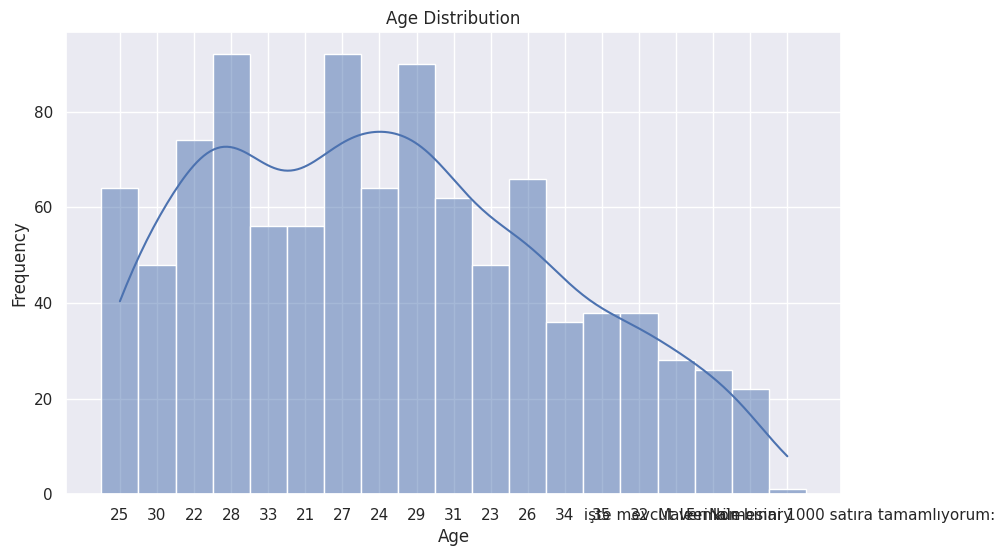

In [113]:
# Plot age distribution
plt.figure(figsize=(10, 6))
sns.histplot(train_df['Age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## 3.3 Gender Distribution¶
Let's visualize the distribution of genders in our training set. This will help us understand the gender diversity within our dataset.

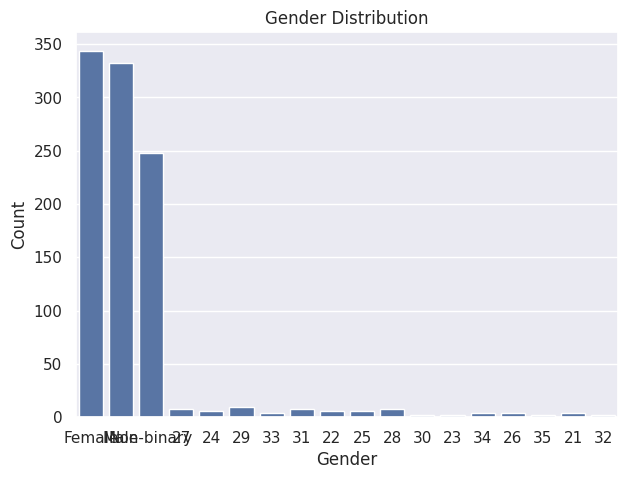

In [114]:
# Plot gender distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Gender', data=train_df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## 3.4 Daily Usage Time by Platform¶
Analyzing how much time users spend on different social media platforms can reveal behavioral patterns. We will visualize the average daily usage time for each platform.

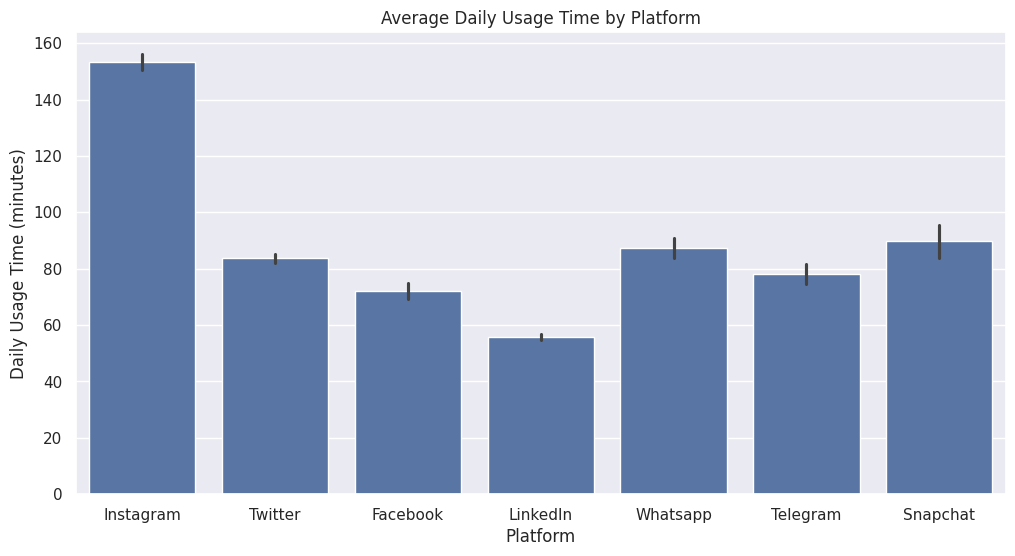

In [115]:
# Plot average daily usage time by platform
plt.figure(figsize=(12, 6))
sns.barplot(x='Platform', y='Daily_Usage_Time (minutes)', data=train_df, estimator=np.mean)
plt.title('Average Daily Usage Time by Platform')
plt.xlabel('Platform')
plt.ylabel('Daily Usage Time (minutes)')
plt.show()

3.5 Dominant Emotion Distribution¶
Finally, let's look at the distribution of dominant emotions among users. This will give us an idea of the most prevalent emotional states represented in our dataset.

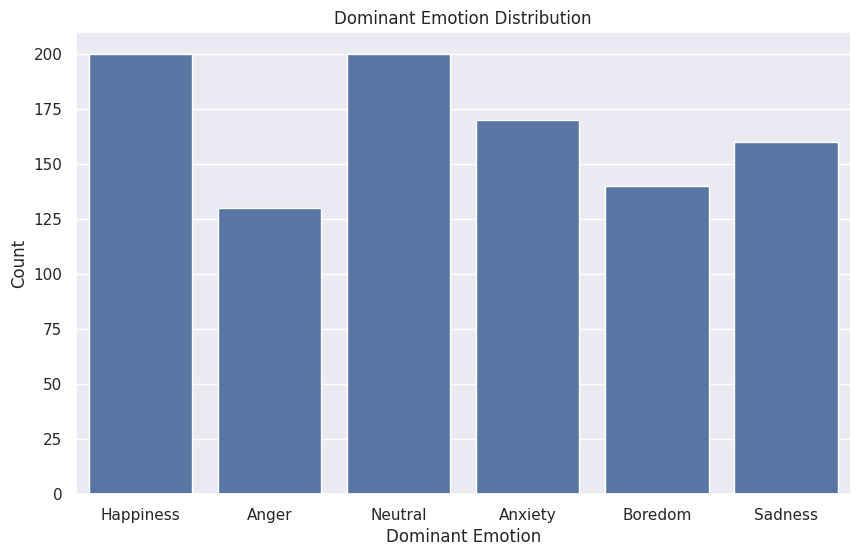

In [116]:
# Plot dominant emotion distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Dominant_Emotion', data=train_df)
plt.title('Dominant Emotion Distribution')
plt.xlabel('Dominant Emotion')
plt.ylabel('Count')
plt.show()

## 4. Data Preprocessing¶
Data preprocessing involves preparing and transforming raw data before it is used in modeling. This step ensures that the data is clean, well-formatted, and ready for training machine learning models.

4.1 Handling Missing Values
We begin by checking for and handling any missing values in the dataset. Missing values can skew the results and affect the performance of machine learning models.

In [117]:
# Check for missing values in the training dataset
print("Missing values in training data:")
print(train_df.isnull().sum())

# Check for missing values in the test dataset
print("\nMissing values in test data:")
print(test_df.isnull().sum())

# Check for missing values in the validation dataset
print("\nMissing values in validation data (before cleanup):")
print(val_df.isnull().sum())

# Function to safely drop any 'Unnamed:' columns
def drop_unnamed_columns(df):
    cols_to_drop = [col for col in df.columns if col.startswith('Unnamed:')]
    if cols_to_drop:
        print(f"Dropping columns from dataframe: {cols_to_drop}")
        return df.drop(columns=cols_to_drop)
    return df

# Apply the function to all dataframes
train_df = drop_unnamed_columns(train_df)
test_df = drop_unnamed_columns(test_df)
val_df = drop_unnamed_columns(val_df)

# Drop 'User_ID' as it's an identifier and not a feature
if 'User_ID' in train_df.columns:
    train_df = train_df.drop(columns=['User_ID'])
if 'User_ID' in test_df.columns:
    test_df = test_df.drop(columns=['User_ID'])
if 'User_ID' in val_df.columns:
    val_df = val_df.drop(columns=['User_ID'])

# Handle 'Age' column conversion to numeric. It was detected as 'object' Dtype previously.
# Convert 'Age' to numeric, coercing errors.
for df in [train_df, test_df, val_df]:
    if 'Age' in df.columns:
        df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

print(f"\nShape of val_df after initial cleanup (dropping 'Unnamed:' and 'User_ID', converting Age): {val_df.shape}")
print(f"Missing values in val_df after initial cleanup:\n{val_df.isnull().sum()}")

# Handling missing values (if any) - here, we'll just drop rows with missing values for simplicity
# In a real-world scenario, you might want to impute missing values instead
train_df = train_df.dropna()
test_df = test_df.dropna()
val_df = val_df.dropna()

print(f"\nShape of val_df after dropna(): {val_df.shape}")
if val_df.empty:
    print("Warning: val_df is still empty after dropping rows with missing values. The validation set might not be used for model training if it remains empty.")

# Verify that there are no more missing values in training data
print("\nMissing values in training data after dropping rows with missing values:")
print(train_df.isnull().sum())

Missing values in training data:
User_ID                       0
Age                           0
Gender                        1
Platform                      1
Daily_Usage_Time (minutes)    1
Posts_Per_Day                 1
Likes_Received_Per_Day        1
Comments_Received_Per_Day     1
Messages_Sent_Per_Day         1
Dominant_Emotion              1
dtype: int64

Missing values in test data:
User_ID                       0
Age                           0
Gender                        0
Platform                      0
Daily_Usage_Time (minutes)    0
Posts_Per_Day                 0
Likes_Received_Per_Day        0
Comments_Received_Per_Day     0
Messages_Sent_Per_Day         0
Dominant_Emotion              0
dtype: int64

Missing values in validation data (before cleanup):
User_ID                       148
Age                           148
Gender                        148
Platform                      148
Daily_Usage_Time (minutes)    148
Posts_Per_Day                 148
Likes_Received

## 4.2 Encoding Categorical Variables¶
Many machine learning algorithms require numerical input. We need to convert categorical variables such as 'Gender' and 'Platform' into numerical values. This process is called encoding. We'll use one-hot encoding to handle these categorical variables.

In [118]:
# One-hot encode the categorical variables for train, test, and validation sets
train_df = pd.get_dummies(train_df, columns=['Gender', 'Platform'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Gender', 'Platform'], drop_first=True)
val_df = pd.get_dummies(val_df, columns=['Gender', 'Platform'], drop_first=True)

# Ensure that the columns match in train, test, and validation sets
# Align the test and validation sets with the training set
missing_cols_test = set(train_df.columns) - set(test_df.columns)
for col in missing_cols_test:
    test_df[col] = 0
test_df = test_df[train_df.columns]

missing_cols_val = set(train_df.columns) - set(val_df.columns)
for col in missing_cols_val:
    val_df[col] = 0
val_df = val_df[train_df.columns]

# Verify the changes
print("Columns in training data:", train_df.columns)
print("\nColumns in test data after encoding and alignment:", test_df.columns)
print("\nColumns in validation data after encoding and alignment:", val_df.columns)

Columns in training data: Index(['Age', 'Daily_Usage_Time (minutes)', 'Posts_Per_Day',
       'Likes_Received_Per_Day', 'Comments_Received_Per_Day',
       'Messages_Sent_Per_Day', 'Dominant_Emotion', 'Gender_Male',
       'Gender_Non-binary', 'Platform_Instagram', 'Platform_LinkedIn',
       'Platform_Snapchat', 'Platform_Telegram', 'Platform_Twitter',
       'Platform_Whatsapp'],
      dtype='object')

Columns in test data after encoding and alignment: Index(['Age', 'Daily_Usage_Time (minutes)', 'Posts_Per_Day',
       'Likes_Received_Per_Day', 'Comments_Received_Per_Day',
       'Messages_Sent_Per_Day', 'Dominant_Emotion', 'Gender_Male',
       'Gender_Non-binary', 'Platform_Instagram', 'Platform_LinkedIn',
       'Platform_Snapchat', 'Platform_Telegram', 'Platform_Twitter',
       'Platform_Whatsapp'],
      dtype='object')

Columns in validation data after encoding and alignment: Index(['Age', 'Daily_Usage_Time (minutes)', 'Posts_Per_Day',
       'Likes_Received_Per_Day', 'Comment

## 4.3 Feature Scaling¶
Feature scaling is essential for neural networks. It ensures that each feature contributes proportionally to the calculations in algorithms and speeds up convergence in gradient-based algorithms. We'll use StandardScaler to scale the features.

In [119]:
# ============================================
# 1. Label Encoding for 6 emotions only
# ============================================

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

label_encoder = LabelEncoder()

# Fit ONLY on training data to define the 6 emotions
label_encoder.fit(
    train_df['Dominant_Emotion']
)

print("Emotion classes (learned from training data):")
print(label_encoder.classes_)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

# Get the classes learned from the training data
allowed_emotions = label_encoder.classes_

# Filter validation and test data to keep only rows with allowed emotions
original_val_shape = val_df.shape
original_test_shape = test_df.shape

# Use .copy() to avoid SettingWithCopyWarning
val_df = val_df[val_df['Dominant_Emotion'].isin(allowed_emotions)].copy()
test_df = test_df[test_df['Dominant_Emotion'].isin(allowed_emotions)].copy()

print(f"\nOriginal val_df shape: {original_val_shape}")
print(f"Filtered val_df shape (keeping only {num_classes} emotions): {val_df.shape}")
print(f"Original test_df shape: {original_test_shape}")
print(f"Filtered test_df shape (keeping only {num_classes} emotions): {test_df.shape}")


# ============================================
# 2. Define features and target variable for each dataset after filtering
# ============================================

X_train = train_df.drop('Dominant_Emotion', axis=1)
X_test = test_df.drop('Dominant_Emotion', axis=1)
X_val = val_df.drop('Dominant_Emotion', axis=1)

# Verify the feature names
print("\nFeature names in train data:", X_train.columns.tolist())
print("Feature names in test data:", X_test.columns.tolist())
print("Feature names in validation data:", X_val.columns.tolist())

# Select only numeric columns for scaling
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Standardize the features using StandardScaler
scaler = StandardScaler()
# Fit scaler on training data and transform all splits
X_train_scaled = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled = scaler.transform(X_test[numeric_columns])

# Only scale X_val_scaled if X_val is not empty
if not X_val.empty:
    X_val_scaled = scaler.transform(X_val[numeric_columns])
else:
    X_val_scaled = np.array([]) # Assign an empty array if X_val is empty

print("Scaled feature sample (first 5 rows of the training data):")
print(X_train_scaled[:5])


# ============================================
# 3. Encode target (y_encoded)
# ============================================

y_train_encoded = label_encoder.transform(
    train_df['Dominant_Emotion']
)

y_val_encoded = label_encoder.transform(
    val_df['Dominant_Emotion']
)

y_test_encoded = label_encoder.transform(
    test_df['Dominant_Emotion']
)


# ============================================
# 4. One-hot encode (y_one_hot)
# ============================================

y_train_one_hot = to_categorical(
    y_train_encoded,
    num_classes=num_classes
)

y_val_one_hot = to_categorical(
    y_val_encoded,
    num_classes=num_classes
)

y_test_one_hot = to_categorical(
    y_test_encoded,
    num_classes=num_classes
)


# ============================================
# 5. Check shapes
# ============================================

print("\nY_train shape:", y_train_one_hot.shape)
print("Y_val shape:", y_val_one_hot.shape)
print("Y_test shape:", y_test_one_hot.shape)

# Print scaled X shapes as they are inputs to the next step
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


Emotion classes (learned from training data):
['Anger' 'Anxiety' 'Boredom' 'Happiness' 'Neutral' 'Sadness']
Number of classes: 6

Original val_df shape: (133, 15)
Filtered val_df shape (keeping only 6 emotions): (132, 15)
Original test_df shape: (102, 15)
Filtered test_df shape (keeping only 6 emotions): (102, 15)

Feature names in train data: ['Age', 'Daily_Usage_Time (minutes)', 'Posts_Per_Day', 'Likes_Received_Per_Day', 'Comments_Received_Per_Day', 'Messages_Sent_Per_Day', 'Gender_Male', 'Gender_Non-binary', 'Platform_Instagram', 'Platform_LinkedIn', 'Platform_Snapchat', 'Platform_Telegram', 'Platform_Twitter', 'Platform_Whatsapp']
Feature names in test data: ['Age', 'Daily_Usage_Time (minutes)', 'Posts_Per_Day', 'Likes_Received_Per_Day', 'Comments_Received_Per_Day', 'Messages_Sent_Per_Day', 'Gender_Male', 'Gender_Non-binary', 'Platform_Instagram', 'Platform_LinkedIn', 'Platform_Snapchat', 'Platform_Telegram', 'Platform_Twitter', 'Platform_Whatsapp']
Feature names in validation data

## Building the GRU Neural Network¶
In this section, we will build a GRU (Gated Recurrent Unit) neural network using TensorFlow. GRUs are a type of recurrent neural network (RNN) that are well-suited for processing sequential data.

5.1 Data Preparation for GRU¶

In [120]:
# Ensure the input data is in the correct format (3D array for GRU)
X_train_gru = np.expand_dims(X_train_scaled, axis=1)
X_test_gru = np.expand_dims(X_test_scaled, axis=1)

# Only expand dimensions for X_val_scaled if it's not empty
if X_val_scaled.size > 0:
    X_val_gru = np.expand_dims(X_val_scaled, axis=1)
else:
    X_val_gru = np.array([]) # Assign an empty array if X_val_scaled is empty

# Print X shapes
print("X_train shape:", X_train_gru.shape)
print("X_val shape:", X_val_gru.shape)
print("X_test shape:", X_test_gru.shape)

X_train shape: (924, 1, 6)
X_val shape: (132, 1, 6)
X_test shape: (102, 1, 6)


## 5.2 Custom Activation Function¶
We will define a custom activation function that will be used in the GRU layers. This function will be tailored specifically for our model and will add a unique characteristic to it.

In [121]:
from tensorflow.keras.utils import register_keras_serializable

# Define a custom and more effective activation function combining multiple properties
@register_keras_serializable()
def custom_activation(x):
    # Combination of sigmoid, tanh, ReLU, and a linear transformation
    tanh = tf.keras.activations.tanh(x)
    relu = tf.keras.activations.relu(x)
    return tanh + relu * 1.5

# Test the custom activation function
print("Testing custom activation function with sample input:")
sample_input = np.array([0.5, 1.0, 1.5, 2.0])
print(custom_activation(sample_input))

Testing custom activation function with sample input:
tf.Tensor([1.21211716 2.26159416 3.15514825 3.96402758], shape=(4,), dtype=float64)


## 5.3 Model Architecture¶
Let's now define the architecture of our GRU neural network. Our model will consist of multiple GRU layers, followed by dense layers to bring the number of parameters to around 105K.

In [122]:
# Clear any existing models in the session
tf.keras.backend.clear_session()

# Build the GRU neural network with the updated custom activation function
model = Sequential()

# Adding the first GRU layer with the updated custom activation function
model.add(GRU(32, activation="relu", return_sequences=True, input_shape=(1, X_train_gru.shape[2])))
model.add(Dropout(0.2))

# Adding additional GRU layers
model.add(GRU(128, activation=custom_activation, return_sequences=True))
model.add(Dropout(0.2))

model.add(GRU(64, activation=custom_activation, return_sequences=False))
model.add(Dropout(0.2))

# Adding a dense layer for classification
model.add(Dense(32, activation="tanh"))
model.add(Dropout(0.2))

# Output layer with the number of classes for the target variable
output_classes = y_train_one_hot.shape[1]
model.add(Dense(output_classes, activation='softmax'))

# Summary of the model
model.summary()

# Confirm the total parameters to ensure it's around 2 million
total_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print("Total trainable parameters: ", total_params)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 32)          │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 1, 128)         │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,574 (412.40 KB)

 Trainable params: 105,574 (412.40 KB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters:  105574


## 5.4 Model Compilation¶
We need to compile our model using an appropriate optimizer and loss function. We will use 'adam' as the optimizer and 'categorical_crossentropy' as the loss function since we are performing multi-class classification.

In [123]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary again to ensure everything is correct
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 32)          │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 1, 128)         │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,574 (412.40 KB)

 Trainable params: 105,574 (412.40 KB)

 Non-trainable params: 0 (0.00 B)

## 5.5 Model Training¶
Let's train our GRU model using the training data. We will use the validation data to evaluate the model's performance after each epoch.

Validation data is present, EarlyStopping will monitor 'val_loss'.
Epoch 1/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 237ms/step - accuracy: 0.3355 - loss: 1.6631 - val_accuracy: 0.4015 - val_loss: 1.4941
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4437 - loss: 1.4280 - val_accuracy: 0.4773 - val_loss: 1.3668
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4665 - loss: 1.3592 - val_accuracy: 0.4697 - val_loss: 1.3190
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5162 - loss: 1.2922 - val_accuracy: 0.5227 - val_loss: 1.2781
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5346 - loss: 1.2426 - val_accuracy: 0.5303 - val_loss: 1.2599
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5628 - loss: 1.1972 - val_accuracy: 0.5379 - val_loss: 1.2453
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5552 - loss: 1.1836 - val_accuracy: 0.5152 - val_loss: 1.2394
Epoch 8/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s

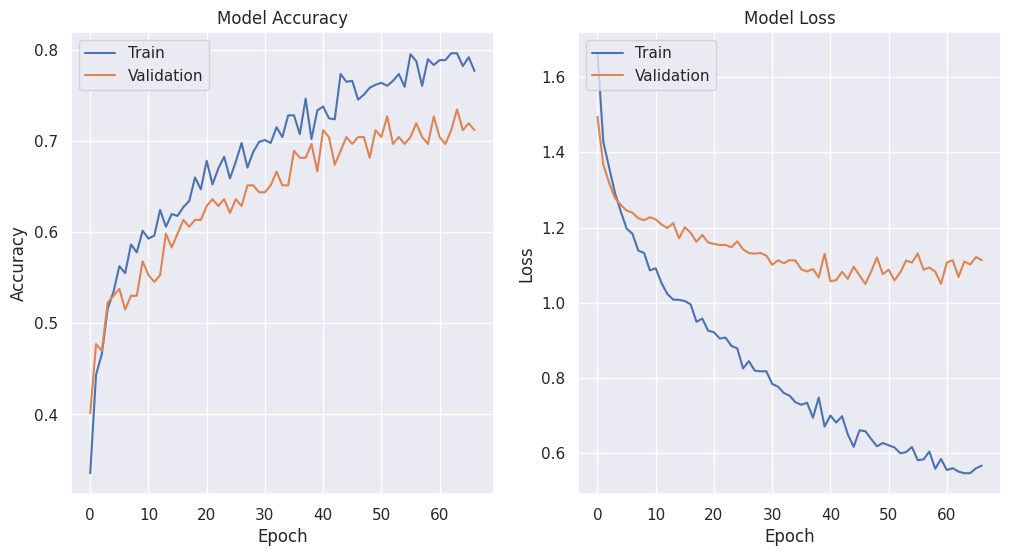

In [124]:
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

# Conditionally set the monitor for EarlyStopping
monitor_metric = 'val_loss'
if X_val_gru.size == 0 or y_val_one_hot.size == 0:
    monitor_metric = 'loss'
    print(f"Validation data is empty, EarlyStopping will monitor '{monitor_metric}'.")
else:
    print(f"Validation data is present, EarlyStopping will monitor '{monitor_metric}'.")

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor=monitor_metric,  # Monitor loss or val_loss based on data availability
    patience=20,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Conditionally train the model with validation data if available
if X_val_gru.size > 0 and y_val_one_hot.size > 0:
    history = model.fit(X_train_gru, y_train_one_hot, epochs=300, batch_size=32,
                        validation_data=(X_val_gru, y_val_one_hot),
                        callbacks=[early_stopping])
else:
    history = model.fit(X_train_gru, y_train_one_hot, epochs=300, batch_size=32,
                        callbacks=[early_stopping]) # Add early stopping even without validation_data by monitoring loss

# Save the model using the recommended Keras native format
model.save('gru_emotion_model.keras')

# Plot the training and validation loss and accuracy
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])

# Only plot validation accuracy if it exists in history
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'])
    plt.legend(['Train', 'Validation'], loc='upper left')
else:
    plt.legend(['Train'], loc='upper left')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])

# Only plot validation loss if it exists in history
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'])
    plt.legend(['Train', 'Validation'], loc='upper left')
else:
    plt.legend(['Train'], loc='upper left')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

6. Model Evaluation¶

After training our GRU neural network, it is essential to evaluate its performance on unseen data. This helps us understand how well the model generalizes to new data.

We will evaluate our model using the test dataset. The metrics we consider include accuracy, loss, and a confusion matrix to give detailed insights into the model's performance.

6.1 Evaluating on Test Set
First, we will evaluate our model on the test dataset using accuracy and loss metrics. This will give us a primary understanding of the model's performance on unseen data.

In [125]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_gru, y_test_one_hot)
print(f"\nTest Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.8137 - loss: 0.5356

Test Loss: 0.5356117486953735
Test Accuracy: 0.813725471496582


## Confusion Matrix and Classification Report¶

To gain deeper insights into our model's performance, we will create a confusion matrix and a classification report. This will help us understand how well the model is performing for each class.

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step

Classification Report:
              precision    recall  f1-score   support

       Anger       0.75      0.67      0.71         9
     Anxiety       0.75      0.82      0.78        22
     Boredom       0.75      0.94      0.83        16
   Happiness       0.92      0.85      0.88        13
     Neutral       0.86      0.89      0.88        28
     Sadness       0.89      0.57      0.70        14

    accuracy                           0.81       102
   macro avg       0.82      0.79      0.80       102
weighted avg       0.82      0.81      0.81       102



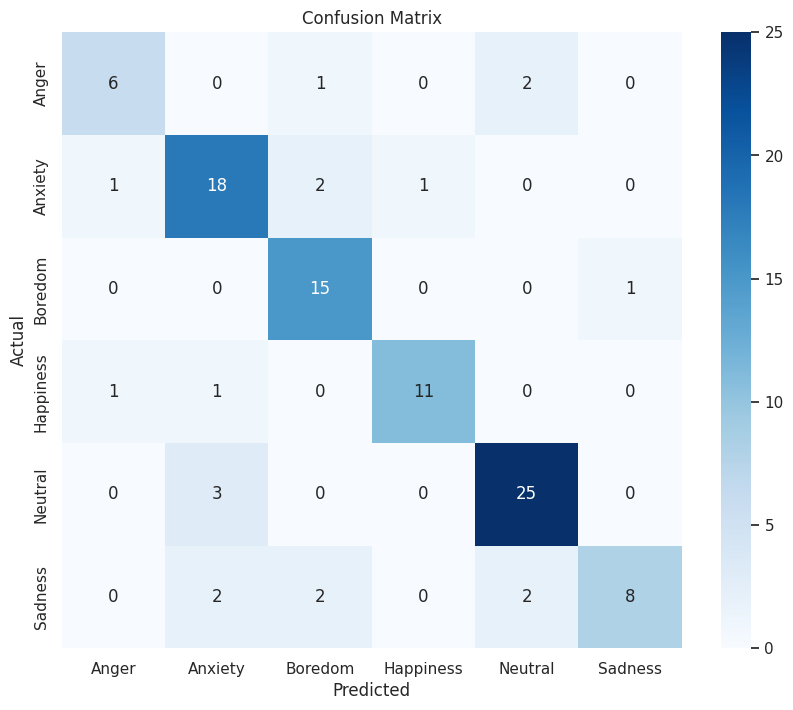

In [126]:
# Predict probabilities for the test set
y_test_prob = model.predict(X_test_gru)

# Get predicted classes from probabilities
y_test_pred_classes = np.argmax(y_test_prob, axis=1)

# Get the unique labels present in the true test data
actual_labels = np.unique(y_test_encoded)

# Get the corresponding target names from the label encoder
target_names_for_report = label_encoder.classes_[actual_labels]

# Generate classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_test_pred_classes,
        labels=actual_labels, # Explicitly pass the labels present in the data
        target_names=target_names_for_report, # Use only the relevant target names
        zero_division=0
    )
)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred_classes, labels=actual_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    xticklabels=target_names_for_report, # Use relevant target names for x-axis
    yticklabels=target_names_for_report, # Use relevant target names for y-axis
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## check class imbalnce issue

In [127]:
print(train_df['Dominant_Emotion'].value_counts())


Dominant_Emotion
Happiness    186
Neutral      184
Anxiety      156
Sadness      146
Boredom      130
Anger        122
Name: count, dtype: int64


## save best model

In [128]:
model.save("gru_emotion_model_clean.keras")
print("Clean model saved successfully.")

Clean model saved successfully.


saving the scaler object

In [129]:
import pickle
import os

# Save the scaler object
scaler_filename = 'scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
print(f"Scaler saved successfully as '{scaler_filename}'")

# Save the label_encoder object
label_encoder_filename = 'label_encoder.pkl'
with open(label_encoder_filename, 'wb') as file:
    pickle.dump(label_encoder, file)
print(f"Label encoder saved successfully as '{label_encoder_filename}'")

# Verify model.output_shape and len(label_encoder.classes_)
# Assuming 'best_model' is the final trained model from the tuner, if not, use 'model'
# Load the best model if it's not already in scope or if you want to be sure you're using the saved one
if 'best_model' in locals():
    final_model = best_model
elif os.path.exists('best_tuned_gru_emotion_model.keras'):
    from tensorflow.keras.models import load_model
    from tensorflow.keras.utils import get_custom_objects

    # Make sure custom_activation is registered before loading
    get_custom_objects()['custom_activation'] = custom_activation

    final_model = load_model('best_tuned_gru_emotion_model.keras')
elif os.path.exists('gru_emotion_model.keras'):
    from tensorflow.keras.models import load_model
    from tensorflow.keras.utils import get_custom_objects

    # Make sure custom_activation is registered before loading
    get_custom_objects()['custom_activation'] = custom_activation

    final_model = load_model('gru_emotion_model.keras')
else:
    print("Warning: No saved model found to verify output shape.")
    final_model = None

if final_model:
    print(f"\nOutput shape of the model: {final_model.output_shape}")
    print(f"Number of classes from label encoder: {len(label_encoder.classes_)}")

Scaler saved successfully as 'scaler.pkl'
Label encoder saved successfully as 'label_encoder.pkl'

Output shape of the model: (None, 7)
Number of classes from label encoder: 6


hyper tunning the model

In [130]:
!pip install keras-tuner

In [135]:
import shutil

# Define the directory to be cleared
tuner_dir = 'keras_tuner_dir'

# Check if the directory exists and remove it
if os.path.exists(tuner_dir):
    shutil.rmtree(tuner_dir)
    print(f"Removed existing Keras Tuner directory: {tuner_dir}")
else:
    print(f"Keras Tuner directory does not exist: {tuner_dir}")

# Re-import keras_tuner to ensure a clean state, though not strictly necessary after directory removal
import keras_tuner as kt

Removed existing Keras Tuner directory: keras_tuner_dir


In [136]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping

def build_model(hp):
    tf.keras.backend.clear_session() # Clear session for each model built by the tuner
    model = Sequential()

    # Helper to get activation function. custom_activation is defined in cell 6lIQVjlppu9o.
    def get_activation(activation_name):
        if activation_name == 'custom_activation':
            # This relies on custom_activation being globally accessible from cell 6lIQVjlppu9o
            return custom_activation
        return activation_name

    # Tune the number of GRU units in the first layer
    hp_gru_units_1 = hp.Int('gru_units_1', min_value=16, max_value=64, step=16)
    hp_gru_activation_1_name = hp.Choice('gru_activation_1', values=['relu', 'tanh', 'custom_activation'])
    model.add(GRU(units=hp_gru_units_1, activation=get_activation(hp_gru_activation_1_name), return_sequences=True,
                  input_shape=(X_train_gru.shape[1], X_train_gru.shape[2])))
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_1))

    # Tune the number of GRU units in the second layer
    hp_gru_units_2 = hp.Int('gru_units_2', min_value=64, max_value=256, step=32)
    hp_gru_activation_2_name = hp.Choice('gru_activation_2', values=['relu', 'tanh', 'custom_activation'])
    model.add(GRU(units=hp_gru_units_2, activation=get_activation(hp_gru_activation_2_name), return_sequences=True))
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_2))

    # Tune the number of GRU units in the third layer
    hp_gru_units_3 = hp.Int('gru_units_3', min_value=32, max_value=128, step=16)
    hp_gru_activation_3_name = hp.Choice('gru_activation_3', values=['relu', 'tanh', 'custom_activation'])
    model.add(GRU(units=hp_gru_units_3, activation=get_activation(hp_gru_activation_3_name), return_sequences=False))
    hp_dropout_3 = hp.Float('dropout_3', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_3))

    # Tune the number of units in the dense layer
    hp_dense_units = hp.Int('dense_units', min_value=16, max_value=64, step=16)
    hp_dense_activation_name = hp.Choice('dense_activation', values=['relu', 'tanh', 'custom_activation'])
    model.add(Dense(units=hp_dense_units, activation=get_activation(hp_dense_activation_name)))
    hp_dropout_4 = hp.Float('dropout_4', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_4))

    # Output layer
    output_classes = y_train_one_hot.shape[1]
    model.add(Dense(output_classes, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize the Keras Tuner
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train for each trial to reduce variance
    directory='keras_tuner_dir',
    project_name='gru_emotion_tuning'
)

# Print a summary of the search space
print("Search space summary:")
tuner.search_space_summary()

# Define EarlyStopping callback for the tuner's search
early_stopping_tuner = EarlyStopping(
    monitor='val_loss',
    patience=10, # Reduced patience for quicker tuning
    restore_best_weights=True
)

print("\nStarting hyperparameter search...")
# Perform the hyperparameter search
# Since X_val_gru and y_val_one_hot are available, use them for validation_data
tuner.search(X_train_gru, y_train_one_hot,
             epochs=50, # A moderate number of epochs for tuning, EarlyStopping will manage it
             batch_size=32,
             validation_data=(X_val_gru, y_val_one_hot),
             callbacks=[early_stopping_tuner])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBest hyperparameters found by Keras Tuner:")
print(best_hps.values)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]
print("\nSummary of the best model found:")
best_model.summary()

# Save the best model found by the tuner
best_model.save('best_tuned_gru_emotion_model.keras')
print("\nBest tuned GRU model saved as 'best_tuned_gru_emotion_model.keras'")

Trial 6 Complete [00h 01m 14s]
val_accuracy: 0.5227272808551788

Best val_accuracy So Far: 0.6666666567325592
Total elapsed time: 00h 05m 35s

Search: Running Trial #7

Value             |Best Value So Far |Hyperparameter
48                |32                |gru_units_1
custom_activation |custom_activation |gru_activation_1
0.5               |0.1               |dropout_1
96                |192               |gru_units_2
tanh              |tanh              |gru_activation_2
0.3               |0.1               |dropout_2
48                |128               |gru_units_3
tanh              |tanh              |gru_activation_3
0.2               |0.1               |dropout_3
64                |16                |dense_units
tanh              |relu              |dense_activation
0.3               |0.1               |dropout_4
0.00032867        |0.0010241         |learning_rate

Epoch 1/50
26/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2063 - loss: 1.7847

KeyboardInterrupt: 

## streamlit Application for prediction emotion for socila media

In [133]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf

from tensorflow.keras.models import load_model


# -----------------------------------
# Custom Activation
# -----------------------------------

@tf.keras.utils.register_keras_serializable(
    package="Custom"
)
def custom_activation(x):

    tanh = tf.keras.activations.tanh(x)
    relu = tf.keras.activations.relu(x)

    return tanh + relu * 1.5


# -----------------------------------
# Streamlit Configuration
# -----------------------------------

st.set_page_config(
    page_title="Social Media Emotion Predictor",
    layout="centered"
)


# -----------------------------------
# Load Resources
# -----------------------------------

@st.cache_resource
def load_resources():

    model = load_model(
        "gru_emotion_model_clean.keras",
        custom_objects={
            "custom_activation": custom_activation
        },
        compile=False
    )

    with open("scaler.pkl", "rb") as f:
        scaler = pickle.load(f)

    with open("label_encoder.pkl", "rb") as f:
        label_encoder = pickle.load(f)

    return model, scaler, label_encoder


model, scaler, label_encoder = load_resources()

st.title("😊 Social Media Emotion Prediction")
st.write("Enter social media usage details below to predict the dominant emotion.")

# Layout for inputs for the 6 numeric features used by the GRU model
col1, col2 = st.columns(2)

with col1:
    age = st.number_input("Age", min_value=18, max_value=100, value=30, help="User's age.")
    daily_usage_time = st.number_input("Daily Usage Time (minutes)", min_value=0.0, max_value=300.0, value=90.0, format="%.1f", help="Average daily time spent on social media in minutes.")
    posts_per_day = st.number_input("Posts Per Day", min_value=0.0, max_value=20.0, value=3.0, format="%.1f", help="Average number of posts made per day.")

with col2:
    likes_received_per_day = st.number_input("Likes Received Per Day", min_value=0.0, max_value=200.0, value=30.0, format="%.1f", help="Average number of likes received per day.")
    comments_received_per_day = st.number_input("Comments Received Per Day", min_value=0.0, max_value=50.0, value=10.0, format="%.1f", help="Average number of comments received per day.")
    messages_sent_per_day = st.number_input("Messages Sent Per Day", min_value=0.0, max_value=100.0, value=20.0, format="%.1f", help="Average number of messages sent per day.")

# Preprocess user input
if st.button("Predict Emotion"):
    # Create a DataFrame containing only the 6 numeric features
    numeric_input_data = pd.DataFrame({
        'Age': [float(age)],
        'Daily_Usage_Time (minutes)': [float(daily_usage_time)],
        'Posts_Per_Day': [float(posts_per_day)],
        'Likes_Received_Per_Day': [float(likes_received_per_day)],
        'Comments_Received_Per_Day': [float(comments_received_per_day)],
        'Messages_Sent_Per_Day': [float(messages_sent_per_day)],
    })

    # Scale these numeric features using the pre-fitted StandardScaler
    input_scaled = scaler.transform(numeric_input_data)

    # Expand dimensions to match the GRU model's expected input shape (batch_size, timesteps, features)
    input_gru = np.expand_dims(input_scaled, axis=1)

    # Make prediction - model.predict returns a batch of predictions, so take the first one [0]
    prediction_probabilities = model.predict(input_gru)[0]

    # Determine the predicted class index (0-indexed for the model output)
    predicted_class_index = np.argmax(prediction_probabilities)

    # Get the confidence for the predicted class
    confidence = prediction_probabilities[predicted_class_index]

    st.divider()

    # Display the prediction result
    # Check if the predicted_class_index corresponds to an actual class from label_encoder
    # The to_categorical function might create an extra column at index 0 if the original labels were 0-indexed.
    # The label_encoder.inverse_transform method expects encoded labels that were used during fit.

    # Map model output index to original emotion label using label_encoder
    # Adjusting for potential extra 0-indexed class from to_categorical
    if predicted_class_index < len(label_encoder.classes_):
        predicted_emotion_name = label_encoder.inverse_transform([predicted_class_index])[0]
        st.success(f"Dominant Emotion: **{predicted_emotion_name}** with **{confidence:.2%}** confidence.")
    elif predicted_class_index == len(label_encoder.classes_): # Handle potential +1 shift if label encoder goes 0-5 and model output is 0-6
        # This handles the case where to_categorical might create an extra class for the highest label + 1
        # We need to map this back to the highest label if it's the intent or handle it as an 'unknown' if it's genuinely a dummy class
        # Given the previous discussion, if output is 7 and classes are 6, the 7th index (index 6) might map to actual class 5 (last)
        # Or, more robustly, directly map based on `label_encoder.classes_`
        all_possible_indices = list(range(len(label_encoder.classes_)))
        if predicted_class_index in all_possible_indices:
             predicted_emotion_name = label_encoder.inverse_transform([predicted_class_index])[0]
             st.success(f"Dominant Emotion: **{predicted_emotion_name}** with **{confidence:.2%}** confidence.")
        else:
             st.warning(f"🤔 Prediction is ambiguous or falls into an undetermined category with {confidence:.2%} confidence.")
    else:
        st.warning(f"🤔 Prediction is ambiguous or falls into an undetermined category with {confidence:.2%} confidence.")

    st.subheader("All Emotion Probabilities:")
    # Display all probabilities using label_encoder.classes_
    for i, prob in enumerate(prediction_probabilities):
        if i < len(label_encoder.classes_):
            emotion_name_for_display = label_encoder.inverse_transform([i])[0]
            st.write(f"- {emotion_name_for_display}: {prob:.2%}")
        else:
            # Handle extra output classes if they exist (e.g., if to_categorical created an extra one)
            st.write(f"- Unknown/Extra Class (Index {i}): {prob:.2%}")

Overwriting app.py


In [134]:
print("Label classes:")
print(label_encoder.classes_)

print(
    "Number of classes:",
    len(label_encoder.classes_)
)

print(
    "Model output shape:",
    model.output_shape
)

Label classes:
['Anger' 'Anxiety' 'Boredom' 'Happiness' 'Neutral' 'Sadness']
Number of classes: 6
Model output shape: (None, 6)


In [138]:
%%writefile requirements.txt
pandas
numpy
seaborn
matplotlib
scikit-learn
tensorflow
keras
streamlit
keras-tuner

Overwriting requirements.txt


In [137]:
!pip install -r requirements.txt

## streamlit Application for  prediction emotion for socila media

In [ ]:
!streamlit run app.py